In [2]:
# importing library 
import pandas as pd
import numpy as np

In [3]:
# loading Dataset
dataset = pd.read_csv('Mall_Customers.csv')

In [4]:
# PreProcessing 
dataset.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
dataset.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
dataset.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
dataset.shape

(200, 5)

In [9]:
dataset.isnull().sum().sum()

0

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
label_encoded_ds = dataset
label_encoded_ds['Genre'] = le.fit_transform(label_encoded_ds['Genre']) 
label_encoded_ds

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40
...,...,...,...,...,...
195,196,0,35,120,79
196,197,0,45,126,28
197,198,1,32,126,74
198,199,1,32,137,18


In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler  = MinMaxScaler()
dataset['Annual Income (k$)'] = le.fit_transform(dataset['Annual Income (k$)']) 
dataset['Spending Score (1-100)'] = le.fit_transform(dataset['Spending Score (1-100)']) 
dataset['Age'] = le.fit_transform(dataset['Age']) 
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,1,0,30
1,2,1,3,0,67
2,3,0,2,1,4
3,4,0,5,1,64
4,5,0,13,2,31
...,...,...,...,...,...
195,196,0,17,61,66
196,197,0,27,62,23
197,198,1,14,62,61
198,199,1,14,63,16


In [12]:
# using groupby
dataset

grouping = dataset.groupby(['Age'])
print(grouping.head())

# Agewise Salary.
sal = dataset.groupby('Age')['Annual Income (k$)'].sum()
print(sal.head())

     CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)
0             1      1    1                   0                      30
1             2      1    3                   0                      67
2             3      0    2                   1                       4
3             4      0    5                   1                      64
4             5      0   13                   2                      31
..          ...    ...  ...                 ...                     ...
187         188      1   10                  58                      56
188         189      0   23                  59                      15
190         191      0   16                  59                      19
192         193      1   15                  60                       6
196         197      0   27                  62                      23

[174 rows x 5 columns]
Age
0    103
1    243
2     96
3     85
4     35
Name: Annual Income (k$), dtype: int64


In [13]:
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,1,0,30
1,2,1,3,0,67
2,3,0,2,1,4
3,4,0,5,1,64
4,5,0,13,2,31
...,...,...,...,...,...
195,196,0,17,61,66
196,197,0,27,62,23
197,198,1,14,62,61
198,199,1,14,63,16


<AxesSubplot:>

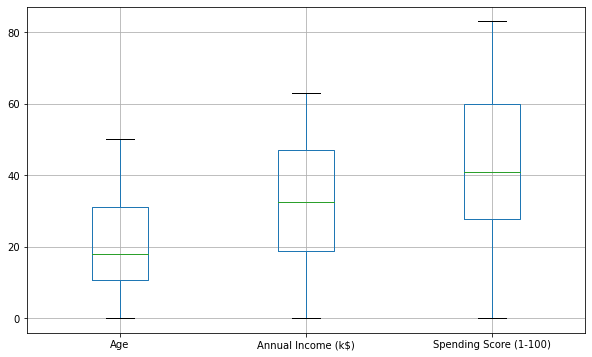

In [14]:
# Checking outlier
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
columns = ['Age','Annual Income (k$)','Spending Score (1-100)']
dataset.boxplot(columns)

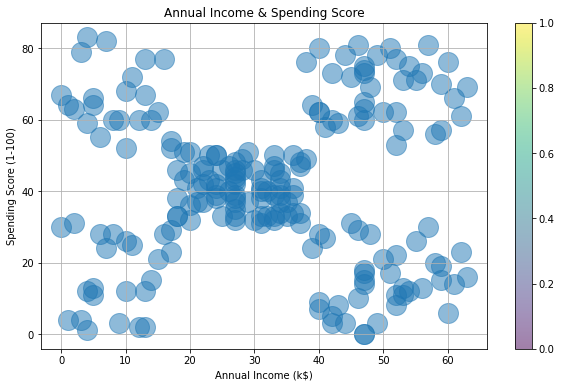

In [15]:
plt.figure(figsize=(10,6))
plt.grid()
plt.title('Annual Income & Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.scatter(dataset['Annual Income (k$)'],dataset['Spending Score (1-100)'],s = 400,alpha = 0.5)
plt.colorbar()